#### Apriori Algorithm

1.  Apriori Algorithm is an unsupervised machine learning algorithm used for

    (a.) Market Based Analysis

    (b.) Product Recommendation

2.  It is used to find out all the items that are used frequently in the dataset.

3.  It even uses "Association Rules" to find out the relation between the requent items used in the dataset.


#### Problem Statement

1. We are given "Grocies_dataset.csv" and we are asked to perform "Apriori Algorithm" on the dataset so as to 

    (a.) find out all the frequently used items used in the dataset.

    (b.) find out the relation between all the frequently used items in the dataset.

    (c.) perform a detailed market based analysis to determine the most valuable product in the dataset

#### Step 1: Import all the necessary libraries

In [405]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    mlxtend.frequent_patterns   import  apriori, association_rules
from    mlxtend.preprocessing       import  TransactionEncoder

#### OBSERVATIONS:

1.  mlxtend ===========> It stands for Machine Learning Extensions used for Association Rules Mining algorithms.

#### Step 2: Load the dataset

In [406]:
df = pd.read_csv("Groceries_dataset.csv")

In [407]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


#### OBSERVATIONS:

1.  The above dataset depicts about the list of items ordered by the customer on the particular date.

#### Step 3: Perform the Data Exploration

In [408]:
#### get the top five records in the dataset

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [409]:
#### get the bottom five records in the dataset

df.tail()

,Member_number,Date,itemDescription
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice
38764,1521,26-12-2014,cat food


In [410]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 38765


In [411]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (38765, 3)


In [412]:
#### get the columns used in the dataset

df.columns

Index(['Member_number', 'Date', 'itemDescription'], dtype='str')

In [413]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB


In [414]:
#### Convert the "Date" str ===========> date

df['Date'] = pd.to_datetime(df['Date'])

C:\Users\DELL\AppData\Local\Temp\ipykernel_11004\2501417396.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [415]:
df.head()

,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


In [416]:
#### Again check the information about the columns in the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38765 non-null  int64         
 1   Date             38765 non-null  datetime64[us]
 2   itemDescription  38765 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 908.7 KB


#### OBSERVATIONS:

1.  The datatype of "Date" column which was initially string has been converted into datetime.

In [417]:
#### Check for the  Unique products of itemdescription


df['itemDescription'].value_counts()

itemDescription
whole milk               2502
other vegetables         1898
rolls/buns               1716
soda                     1514
yogurt                   1334
                         ... 
toilet cleaner              5
bags                        4
baby cosmetics              3
kitchen utensil             1
preservation products       1
Name: count, Length: 167, dtype: int64

In [418]:
df['itemDescription'].unique()

<StringArray>
[       'tropical fruit',            'whole milk',             'pip fruit',
      'other vegetables',            'rolls/buns',            'pot plants',
          'citrus fruit',                  'beef',           'frankfurter',
               'chicken',
 ...
        'flower (seeds)',                  'rice',                   'tea',
        'salad dressing',  'specialty vegetables',        'pudding powder',
           'ready soups',       'make up remover',        'toilet cleaner',
 'preservation products']
Length: 167, dtype: str

#### OBSERVATIONS:

1.  The above items are the unique products in the itemDescription column of the dataset.

In [419]:
#### Get the top 10 products of itemdescription

df['itemDescription'].value_counts().head(10)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The top ten products in the itemdescription column in the dataset is:-------

        (a.)    whole milk

        (b.)    other vegetables

        (c.)    rolls/buns

        (d.)    soda

        (e.)    yogurt

        (f.)    root vegetables

        (g.)    tropical fruit

        (h.)    bottled water

        (i.)    sausage

        (j.)    citrus fruit

#### Step 4:    Perform Data Cleaning and Feature Engineering

In [420]:
#### To check for the missing values in the dataset

df.isnull().sum()

Member_number      0
Date               0
itemDescription    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [421]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,Member_number,Date,itemDescription
5015,2051,2015-09-11,frankfurter
5022,3055,2015-08-18,other vegetables
5044,1994,2015-03-11,whole milk
5055,1682,2015-06-25,pip fruit
5059,4324,2015-01-05,sausage
...,...,...,...
38614,2027,2014-02-26,domestic eggs
38684,2936,2014-03-07,newspapers
38685,2311,2014-03-13,pot plants
38722,3834,2014-05-18,salty snack


#### OBSERVATIONS:

1.  There are a total of 759 duplicate records in the dataset. So remove them.

In [422]:
#### Drop the duplicate records

df = df.drop_duplicates()

In [423]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,Member_number,Date,itemDescription


#### OBSERVATIONS:

1.  After removing the duplicate records from the dataset, there are no duplicate records in the dataset.

In [424]:
#### get the length of the revised dataset

print("Length of the revised dataset is:", len(df))

Length of the revised dataset is: 38006


In [425]:
#### get the shape of the revised dataset

print("Shape of the revised dataset is:", df.shape)

Shape of the revised dataset is: (38006, 3)


In [426]:
df.head()

,Member_number,Date,itemDescription
0,1808,2015-07-21,tropical fruit
1,2552,2015-01-05,whole milk
2,2300,2015-09-19,pip fruit
3,1187,2015-12-12,other vegetables
4,3037,2015-02-01,whole milk


#### Step 5: Create the Transactions

(i) We need to create the transactions in Apriori algorithm because this algorithm only works on transactions.

(ii) This algorithm tries to find out the relationship between the items in the same transactions.

In [427]:
#### Create the transactions

df['Transaction'] = df['Member_number'].astype('str') + "_" + df['Date'].astype('str')

In [428]:
df.head()

,Member_number,Date,itemDescription,Transaction
0,1808,2015-07-21,tropical fruit,1808_2015-07-21
1,2552,2015-01-05,whole milk,2552_2015-01-05
2,2300,2015-09-19,pip fruit,2300_2015-09-19
3,1187,2015-12-12,other vegetables,1187_2015-12-12
4,3037,2015-02-01,whole milk,3037_2015-02-01


In [429]:
#### Group the items by Transactions
transactions = df.groupby('Transaction')['itemDescription'].apply(list).values.tolist()

#### OBSERVATIONS:

1.  Here we are grouping all the itemdescriptions under each transaction.

2.  Then we are converting into each list.

3.  Then we are extracting all the values from the list.

4. Then we are converting them back into the list.

5. Thus all the transactions are created.

In [430]:
transactions

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['sausage', 'whole milk', 'rolls/buns'],
 ['whole milk', 'soda'],
 ['frankfurter', 'soda', 'whipped/sour cream'],
 ['beef', 'white bread'],
 ['frankfurter', 'curd'],
 ['frozen vegetables', 'other vegetables'],
 ['butter', 'whole milk'],
 ['tropical fruit', 'sugar'],
 ['butter milk', 'specialty chocolate'],
 ['frozen meals', 'dental care'],
 ['rolls/buns'],
 ['root vegetables', 'detergent'],
 ['sausage', 'rolls/buns'],
 ['pip fruit', 'whole milk', 'tropical fruit'],
 ['dish cleaner', 'cling film/bags'],
 ['rolls/buns', 'red/blush wine', 'chocolate'],
 ['canned beer', 'frozen fish'],
 ['other vegetables', 'shopping bags'],
 ['root vegetables', 'whole milk', 'pastry'],
 ['whole milk', 'chocolate', 'packaged fruit/vegetables', 'rolls/buns'],
 ['other vegetables', 'hygiene articles'],
 

In [431]:
#### Display the top five transactions of the sample data

print(transactions[:5])

[['whole milk', 'pastry', 'salty snack'], ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['soda', 'pickled vegetables'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles']]


#### Step 6: Convert the Transactions into the numerical format

In [432]:
from mlxtend.preprocessing import TransactionEncoder

#### create the object for Transaction Encoder
te = TransactionEncoder()


#### convert the transactions into the boolen matrix
te_array = te.fit(transactions).transform(transactions)


#### convert the transaction matrix into the dataframe

df = pd.DataFrame(te_array, columns = te.columns_)

df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### OBSERVATIONS:

1.  Transactional Encoding is used to convert all the transactions in the string format into the nuemrical format.

2.  It is done so that all these numerical values can be easily be fed into the ML Models and these values can be easily trained.

3.  ML models only works with the numerical values.

4.  Then the object for Transactional encoding is created.

5.  Using the object for transactional encoding, first all the unique items are learned from the dataset and then all the transaction values are converted in the form of boolean matrix.

6. Now we have obtained the entire transaction matrix in the encoded form of True or False.

#### Step 7: Apply Apriori Algorithm

In [433]:
from mlxtend.frequent_patterns  import apriori, association_rules

#### Apply the apriori on the transaction

frequent_itemsets = apriori(
    df                                                          ,
    min_support                 =               0.001           ,
    use_colnames                =               True
)


#### get the most frequent item sets

frequent_itemsets.head(20)

,support,itemsets
0,0.004010,frozenset({Instant food products})
1,0.021386,frozenset({UHT-milk})
2,0.001470,frozenset({abrasive cleaner})
3,0.001938,frozenset({artif. sweetener})
4,0.008087,frozenset({baking powder})
5,0.001136,frozenset({bathroom cleaner})
6,0.033950,frozenset({beef})
7,0.021787,frozenset({berries})
8,0.016574,frozenset({beverages})
9,0.045312,frozenset({bottled beer})


#### OBSERVATIONS:

1.  Here apriori algorithm is applied on the transactions with the help of the following parameters :--------

    (a.)    df  =========================> Transaction Encoding dataframe

    (b.)    min_support = 0.01 ==========> Items must appear with atleast 1% of the transactions

    (c.)    use_colnames = True  ========> Column names must appear


2. The apriori algorithm has been applied on the transaction encoding dataset and we have obtained the list of all the frequently generated itemsets.

#### Step 8: Generate the Association Rules

In [434]:
from mlxtend.frequent_patterns  import apriori, association_rules

#### Generate the association rules

rules = association_rules(
    frequent_itemsets                       ,
    metric          =           'lift'      ,
    min_threshold   =               1    
)

#### OBSERVATIONS:

1.  Now the association rules have been generated for the frequent item sets.

In [435]:
#### Display the association rules

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({UHT-milk}),frozenset({tropical fruit}),0.021386,0.067767,0.001537,0.071875,1.060617,1.0,8.785064e-05,1.004426,0.058402,0.017544,0.004406,0.047279
1,frozenset({tropical fruit}),frozenset({UHT-milk}),0.067767,0.021386,0.001537,0.022682,1.060617,1.0,8.785064e-05,1.001326,0.061307,0.017544,0.001325,0.047279
2,frozenset({brown bread}),frozenset({beef}),0.037626,0.033950,0.001537,0.040853,1.203301,1.0,2.597018e-04,1.007196,0.175559,0.021947,0.007145,0.043064
3,frozenset({beef}),frozenset({brown bread}),0.033950,0.037626,0.001537,0.045276,1.203301,1.0,2.597018e-04,1.008012,0.174891,0.021947,0.007949,0.043064
4,frozenset({beef}),frozenset({citrus fruit}),0.033950,0.053131,0.001804,0.053150,1.000349,1.0,6.297697e-07,1.000020,0.000361,0.021160,0.000020,0.043556


#### Step 9: Filter the Strong Rules

In [436]:
strong_rules = rules[
    (rules['lift']  >   1.5)    &
    (rules['confidence'] > 0.02)
]

In [437]:
strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
20,frozenset({beverages}),frozenset({sausage}),0.016574,0.060349,0.001537,0.092742,1.536764,1.0,0.000537,1.035704,0.355168,0.020390,0.034474,0.059106
21,frozenset({sausage}),frozenset({beverages}),0.060349,0.016574,0.001537,0.025471,1.536764,1.0,0.000537,1.009129,0.371714,0.020390,0.009046,0.059106
86,frozenset({specialty chocolate}),frozenset({citrus fruit}),0.015973,0.053131,0.001403,0.087866,1.653762,1.0,0.000555,1.038081,0.401735,0.020731,0.036684,0.057141
87,frozenset({citrus fruit}),frozenset({specialty chocolate}),0.053131,0.015973,0.001403,0.026415,1.653762,1.0,0.000555,1.010726,0.417500,0.020731,0.010612,0.057141
122,frozenset({flour}),frozenset({tropical fruit}),0.009757,0.067767,0.001069,0.109589,1.617141,1.0,0.000408,1.046969,0.385385,0.013986,0.044862,0.062684
168,frozenset({pastry}),frozenset({napkins}),0.051728,0.022121,0.001738,0.033592,1.518529,1.0,0.000593,1.011869,0.360095,0.024096,0.011730,0.056071
169,frozenset({napkins}),frozenset({pastry}),0.022121,0.051728,0.001738,0.078550,1.518529,1.0,0.000593,1.029109,0.349192,0.024096,0.028285,0.056071
183,frozenset({processed cheese}),frozenset({root vegetables}),0.010158,0.069572,0.001069,0.105263,1.513019,1.0,0.000363,1.039891,0.342549,0.013594,0.038360,0.060316
228,"frozenset({whole milk, soda})",frozenset({sausage}),0.011629,0.060349,0.001069,0.091954,1.523708,1.0,0.000368,1.034806,0.347750,0.015080,0.033635,0.054836
234,"frozenset({whole milk, yogurt})",frozenset({sausage}),0.011161,0.060349,0.001470,0.131737,2.182917,1.0,0.000797,1.082219,0.548014,0.020992,0.075973,0.078050


#### OBSERVATIONS:

1.  Here we are filtering only strong rules whose

    (a.)    lift value is greater than 1.5

    (b.)    confidence value  is greater than 0.02

2. This is done because many of the rules generated are weak and meaningless.

#### Step 10: Sort only the strong rules

In [438]:
ans = strong_rules.sort_values(
    by  =   'lift'              ,
    ascending = False
)

In [439]:
#### display only the top 10 records

ans.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
239,frozenset({sausage}),"frozenset({whole milk, yogurt})",0.060349,0.011161,0.001470,0.024363,2.182917,1.0,0.000797,1.013532,0.576701,0.020992,0.013351,0.078050
234,"frozenset({whole milk, yogurt})",frozenset({sausage}),0.011161,0.060349,0.001470,0.131737,2.182917,1.0,0.000797,1.082219,0.548014,0.020992,0.075973,0.078050
235,"frozenset({whole milk, sausage})",frozenset({yogurt}),0.008955,0.085879,0.001470,0.164179,1.911760,1.0,0.000701,1.093681,0.481231,0.015748,0.085657,0.090650
87,frozenset({citrus fruit}),frozenset({specialty chocolate}),0.053131,0.015973,0.001403,0.026415,1.653762,1.0,0.000555,1.010726,0.417500,0.020731,0.010612,0.057141
86,frozenset({specialty chocolate}),frozenset({citrus fruit}),0.015973,0.053131,0.001403,0.087866,1.653762,1.0,0.000555,1.038081,0.401735,0.020731,0.036684,0.057141
236,"frozenset({yogurt, sausage})",frozenset({whole milk}),0.005748,0.157923,0.001470,0.255814,1.619866,1.0,0.000563,1.131541,0.384877,0.009065,0.116250,0.132562
122,frozenset({flour}),frozenset({tropical fruit}),0.009757,0.067767,0.001069,0.109589,1.617141,1.0,0.000408,1.046969,0.385385,0.013986,0.044862,0.062684
20,frozenset({beverages}),frozenset({sausage}),0.016574,0.060349,0.001537,0.092742,1.536764,1.0,0.000537,1.035704,0.355168,0.020390,0.034474,0.059106
21,frozenset({sausage}),frozenset({beverages}),0.060349,0.016574,0.001537,0.025471,1.536764,1.0,0.000537,1.009129,0.371714,0.020390,0.009046,0.059106
228,"frozenset({whole milk, soda})",frozenset({sausage}),0.011629,0.060349,0.001069,0.091954,1.523708,1.0,0.000368,1.034806,0.347750,0.015080,0.033635,0.054836


#### OBSERVATIONS:

1.  Here we have obtained the top ten records of the strong rules of Grocies dataset in the decreasing order of lift.

#### Step 11: Visualize Frequent Products and Support vs Confidence

In [440]:
#### Top products

dfnew = pd.read_csv("Groceries_dataset.csv")


ans = dfnew['itemDescription'].value_counts().head(10)

print(ans)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64


#### OBSERVATIONS:

1.  Here we have obtained the top ten itemDescription products.

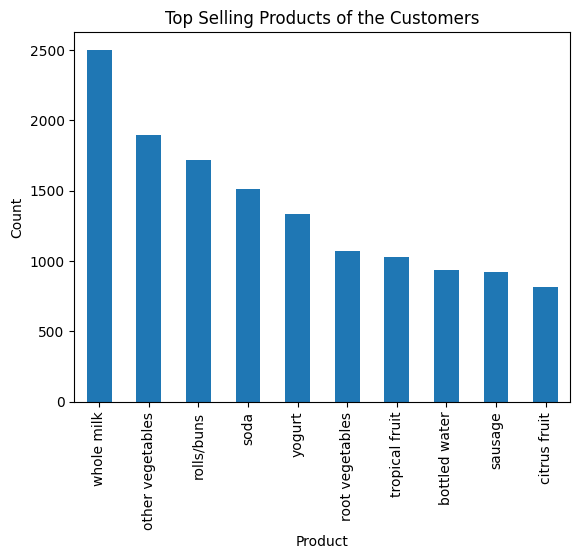

In [441]:
#### get the title of the graph
plt.title("Top Selling Products of the Customers")

#### Plot the bar graph of the itemDescription
ans.plot(kind='bar')

#### get the x-axis of the graph
plt.xlabel("Product")

#### get the y-axis of the graph
plt.ylabel("Count")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph depicts about the top ten most selling products of the customers.

2.  Milk is the most selling product.

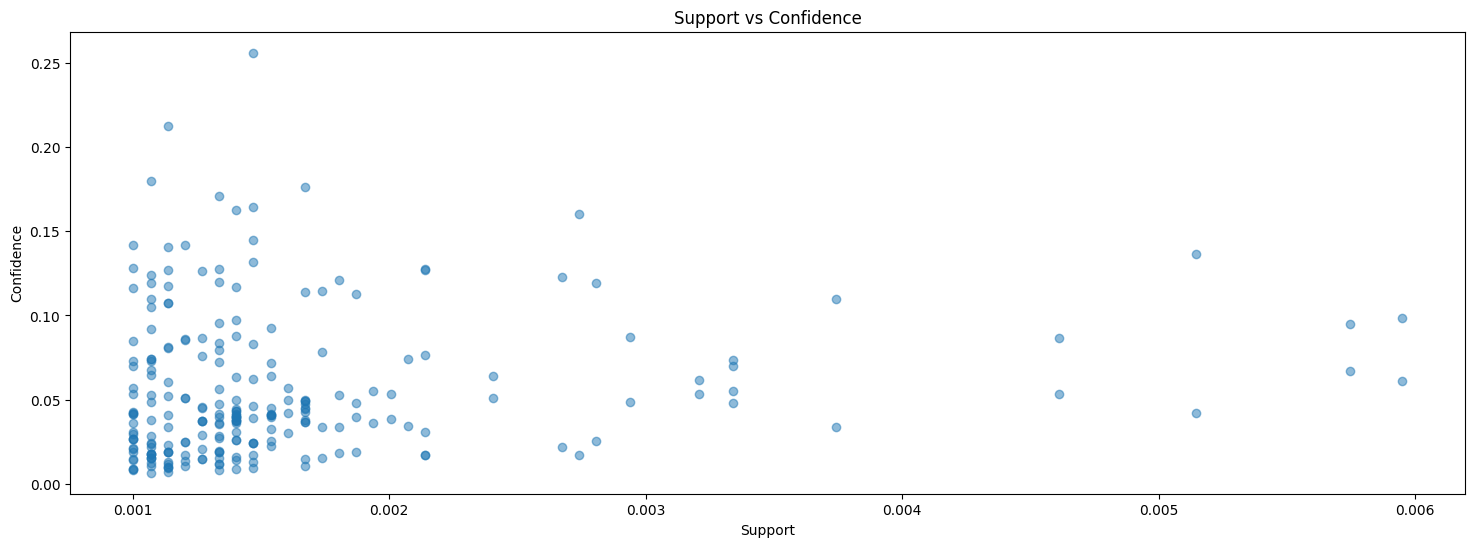

In [442]:
#### Visualize Support vs Confidence

plt.figure(figsize=(18,6))

#### perform the scatter plot for support vs confidence

plt.scatter(
    rules['support']            ,
    rules['confidence']         ,
    alpha = 0.5    
)

plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")

plt.show()

#### CONCLUSIONS:

1.  Each point = Association Rule

2.  Higher confidence = stronger prediction

3.  Higher support = more frequent rule

4.  Best rules usually lie in:

    (a.)    High support

    (b.)    High confidence